In [ ]:
#This is the next step from "ADCP_Anomaly_Training.ipynb"

#Now that I have a trained model (trained on BACAX data), lets try to implement it to find drop-outs 
#I am applying this to find drop-outs in BACUS 2 MHZ data

#Kernel:
#adcp_anomaly_env

In [5]:
# Run the classification model on ADCP data from scan_data_download
# So, lets test that it works as expected

import sys
from pathlib import Path

# Ensure repo root is available when running this cell independently
repo_root = Path().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

import src

# For debugging hot-reload during notebook iteration
#import importlib
#importlib.reload(src.detect_nortek_dropouts)

#EVERYTHING ABOVE THIS LINE IS FOR DEBUGGING. Once working, delete stuff above.

from src.detect_nortek_dropouts import run_classify


#OPTION 1: Most basic run: Use existing 24 hr h5 files. However, all h5 files in the folder will be deleted once complete.
# h5_monthly_folder = None
# h5_24hr_folder = r'F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\'
# run_classify(h5_monthly_folder, h5_24hr_folder)


# OPTION 2: Convert mat files to h5
h5_monthly_folder = r'F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_files\\' 
h5_24hr_folder = r'F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\'
mat_path = [r'F:\Documents\Projects\ADCP\scan_for_data\BACUS\ADCP2MHZ\\20260101\\']
#run_classify(h5_monthly_folder, h5_24hr_folder, mat_path=mat_path)

# OPTION 3: Specify a model to use - NOTE: The Resnet models take a LONG time to run, whereas the default CNN is VERY fast
model_path = r"F:\Documents\GitHub\ml_development\ADCP_ML\src\\models\\" + "best_model_resnet18.pt"
run_classify(h5_monthly_folder, h5_24hr_folder, mat_path=mat_path, model_path=model_path)


📌 Initializing ResNet model (resnet18)


c:\Users\slonimer\AppData\Local\miniconda3\envs\adcp_anomaly_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\slonimer\AppData\Local\miniconda3\envs\adcp_anomaly_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



=== Starting Evaluation on Test Set ===
{'BarkleyUpperSlope_UpperSlopeSouth_AcousticDopplerCurrentProfiler2MHz_20260101T000000Z_20260201T000000Z-Ensemble300s_binMapNearest.mat', 'API_record.mat'}
Failed to prepare one mat file: 'meta'

== META ==
  deviceID: <class 'int'> (11203)
  creationDate: <class 'str'> (20260218T185645Z)
  deviceName: <class 'str'> (Nortek Aquadopp HR-Profiler 2 MHz ASP2699 AQD2973)
  deviceCode: <class 'str'> (NTAquadoppHRCP2973)
  deviceCategory: <class 'str'> (Acoustic Doppler Current Profiler 2 MHz)
  deviceCategoryCode: <class 'str'> (ADCP2MHZ)
  lat: <class 'float'> (48.42675849)
  lon: <class 'float'> (-126.17460632)
  depth: <class 'int'> (392)
  deviceHeading: <class 'int'> (0)
  devicePitch: <class 'float'> (nan)
  deviceRoll: <class 'float'> (nan)
  siteName: <class 'str'> (UpperSlope_South_AQD_2019-09)
  locationName: <class 'str'> (Barkley Canyon)
  stationCode: <class 'str'> (BACUS)
  dataQualityComments: array shape (0,), dtype <U1
  MobilePositi

{'BarkleyUpperSlope_UpperSlopeSouth_AcousticDopplerCurrentProfiler2MHz_20230701T000000Z_20230801T000000Z-Ensemble300s_binMapNearest.mat'}
Skipping (already exists): F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_files\\BarkleyUpperSlope_UpperSlopeSouth_AcousticDopplerCurrentProfiler2MHz_20230701T000000Z_20230801T000000Z-Ensemble300s_binMapNearest.h5
File already exists, skipping: F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\20230701T000230_20230702T000229.h5
File already exists, skipping: F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\20230702T000000_20230702T235959.h5
File already exists, skipping: F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\20230703T000000_20230703T235959.h5
File already exists, skipping: F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\20230704T000000_20230704T235959.h5
File already exists, skipping: F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\20230705T000000_20230705T235959.h5
File already exists, skipping: F:\Documents\Projects\ML\AD

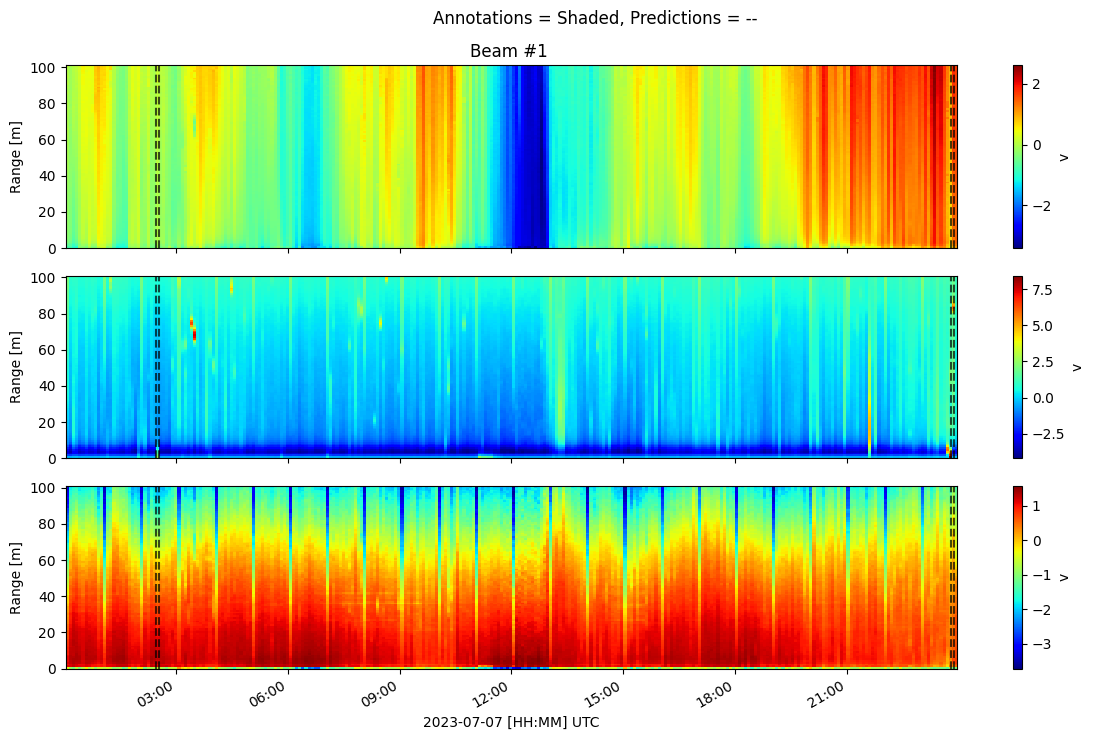

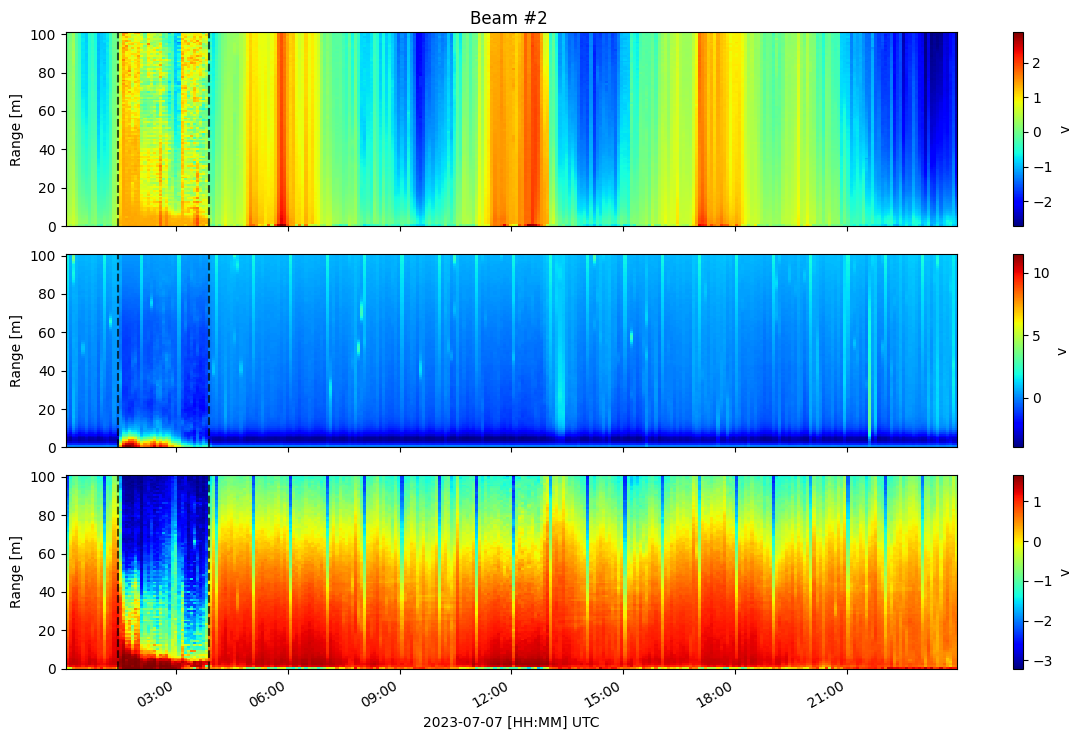

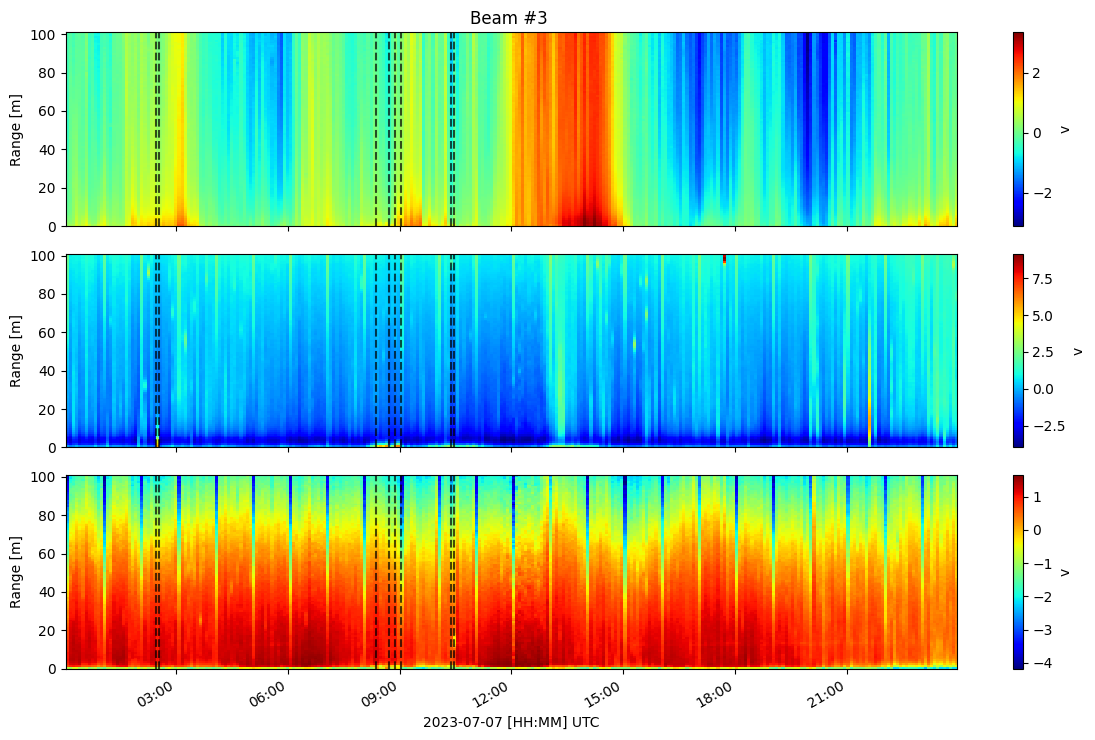

Drop-outs found in Beam [19]! In F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\20230707T000000_20230707T235959.h5


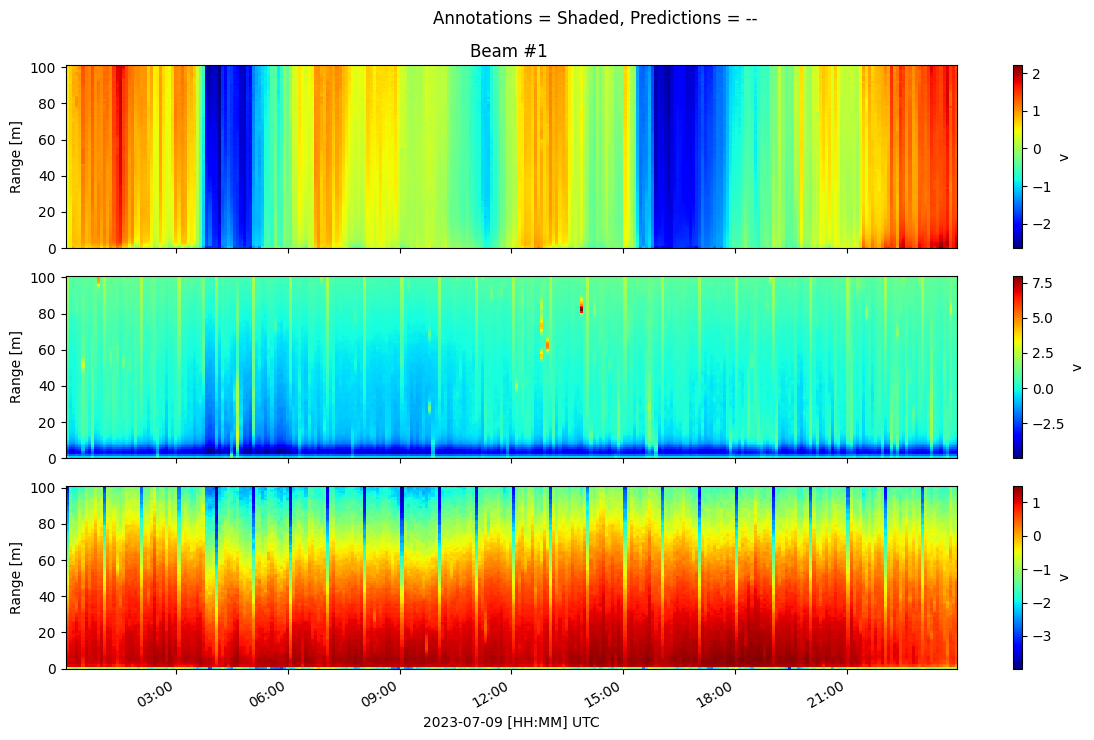

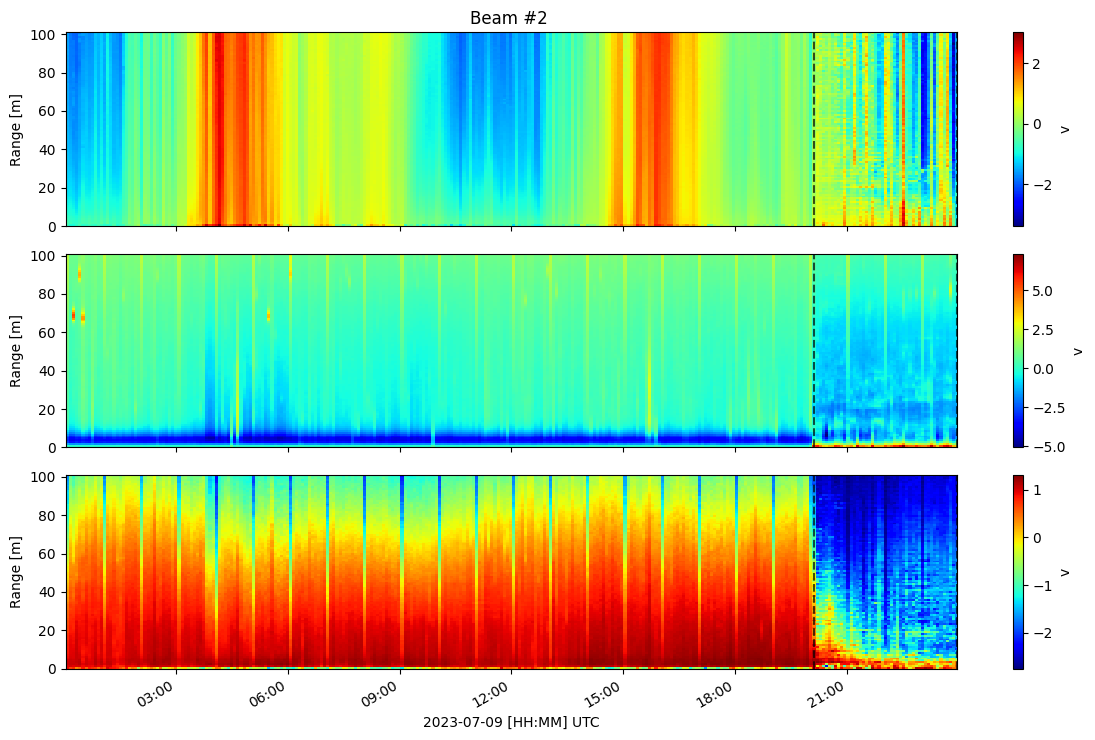

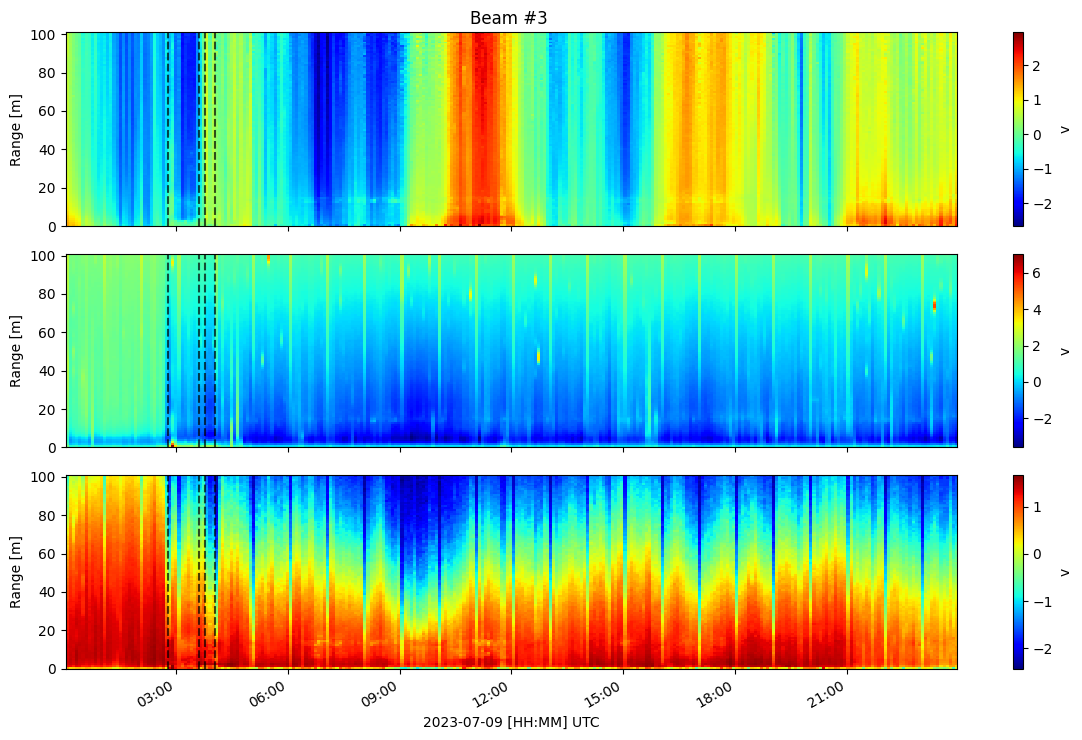

Drop-outs found in Beam [4, 5]! In F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\20230709T000000_20230709T235959.h5


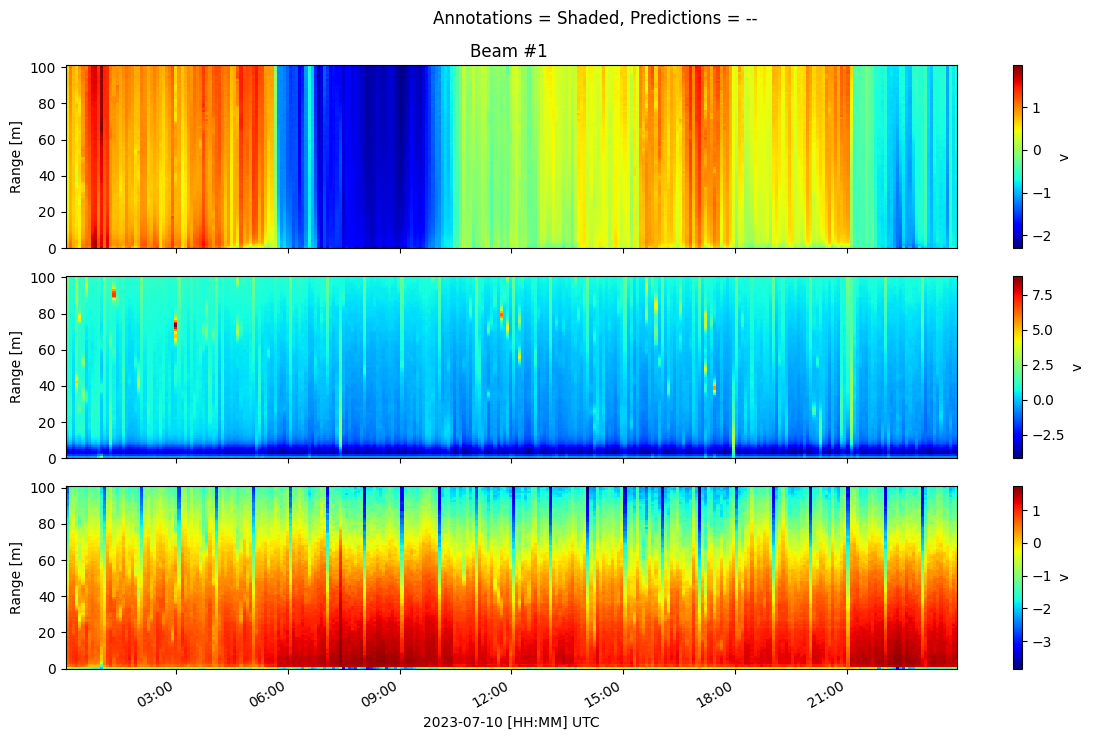

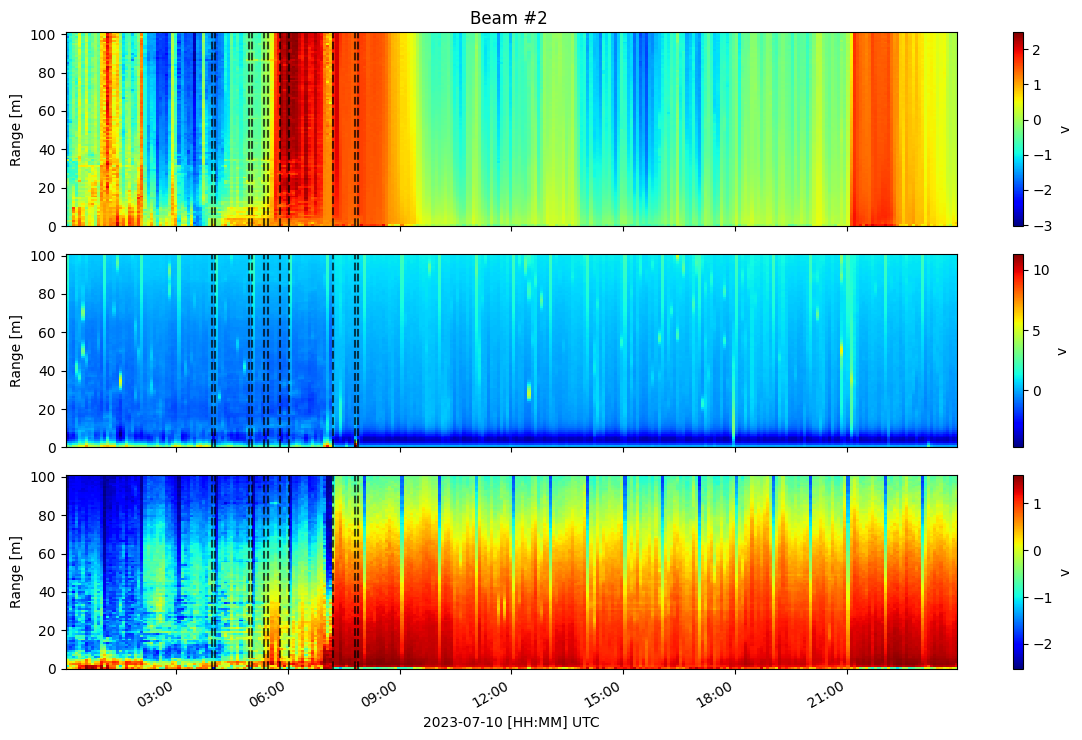

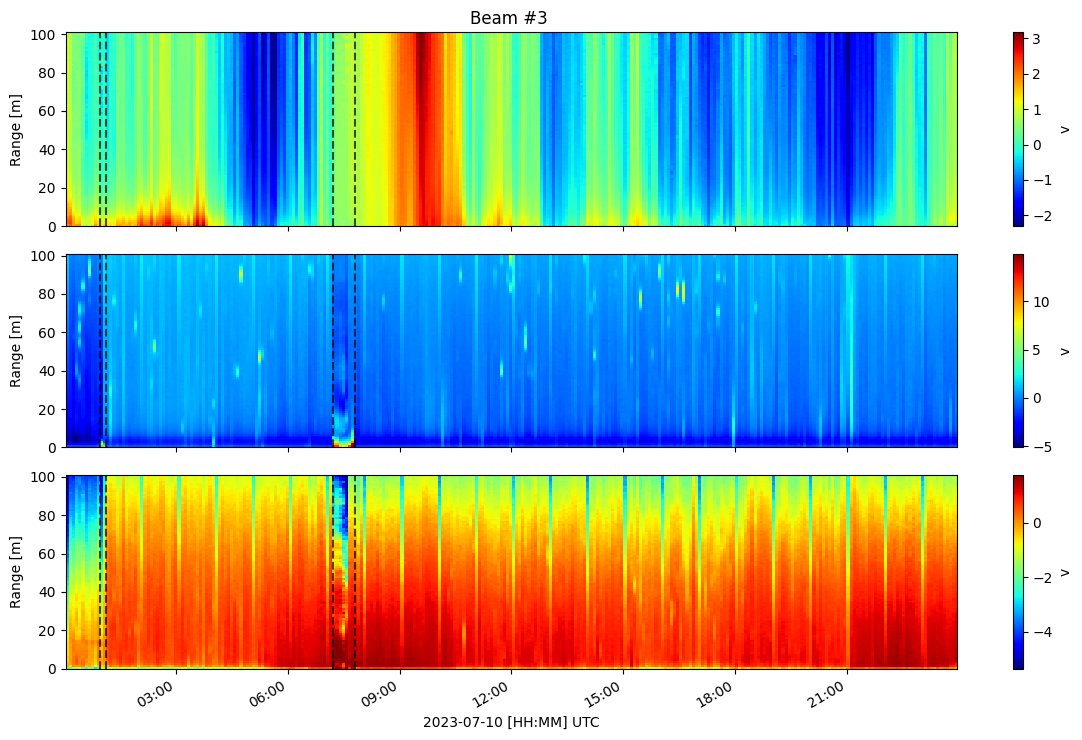

Drop-outs found in Beam [7]! In F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\20230710T000000_20230710T235959.h5


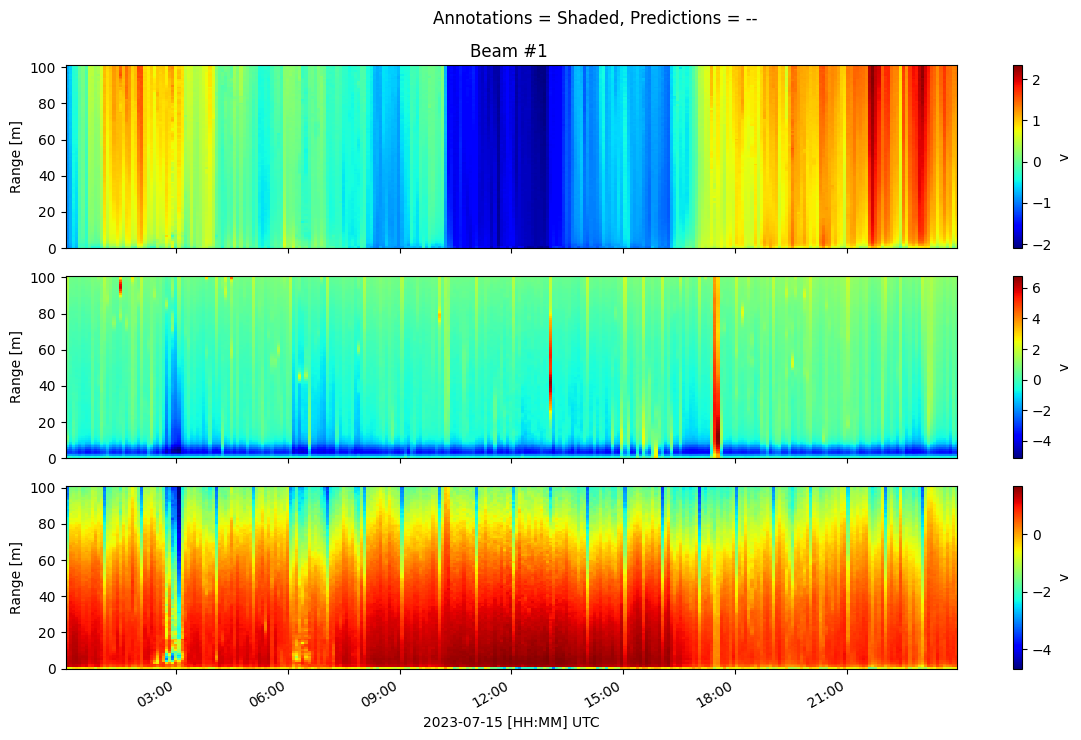

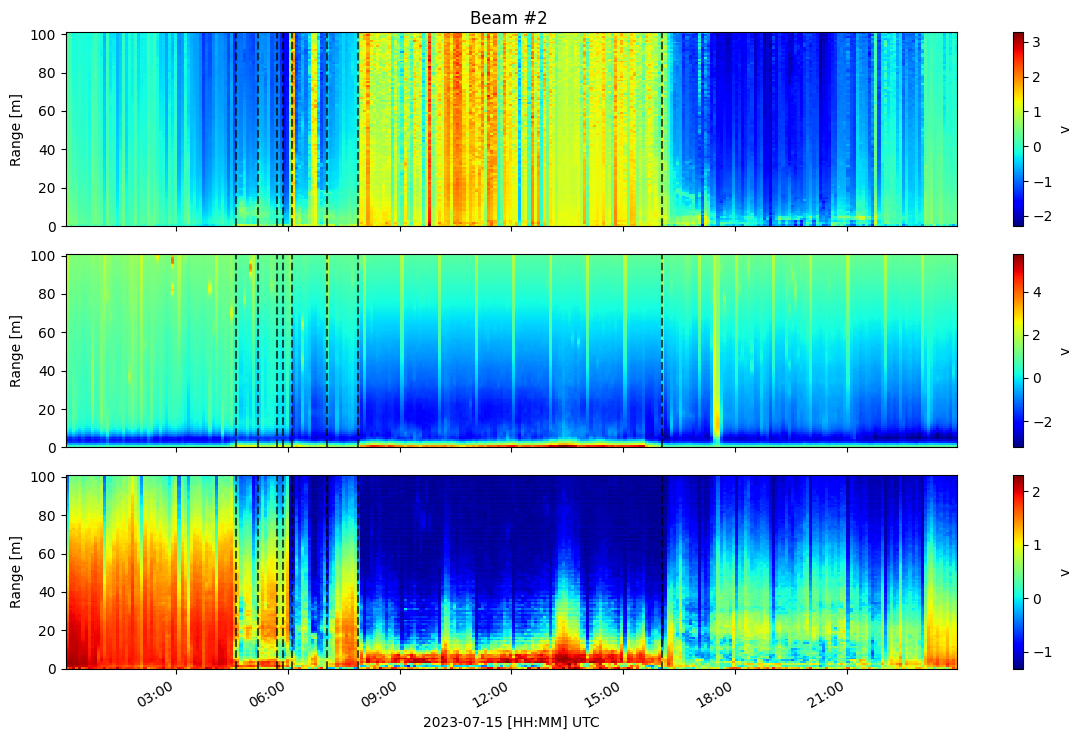

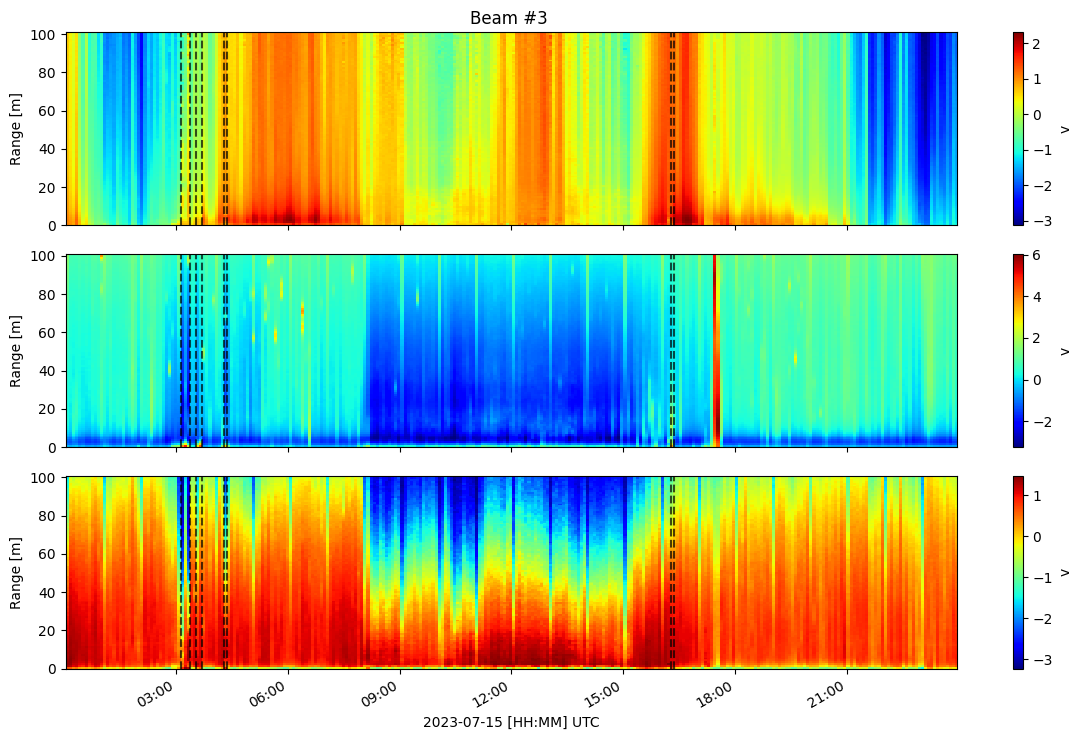

Drop-outs found in Beam [1]! In F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\20230715T000000_20230715T235959.h5


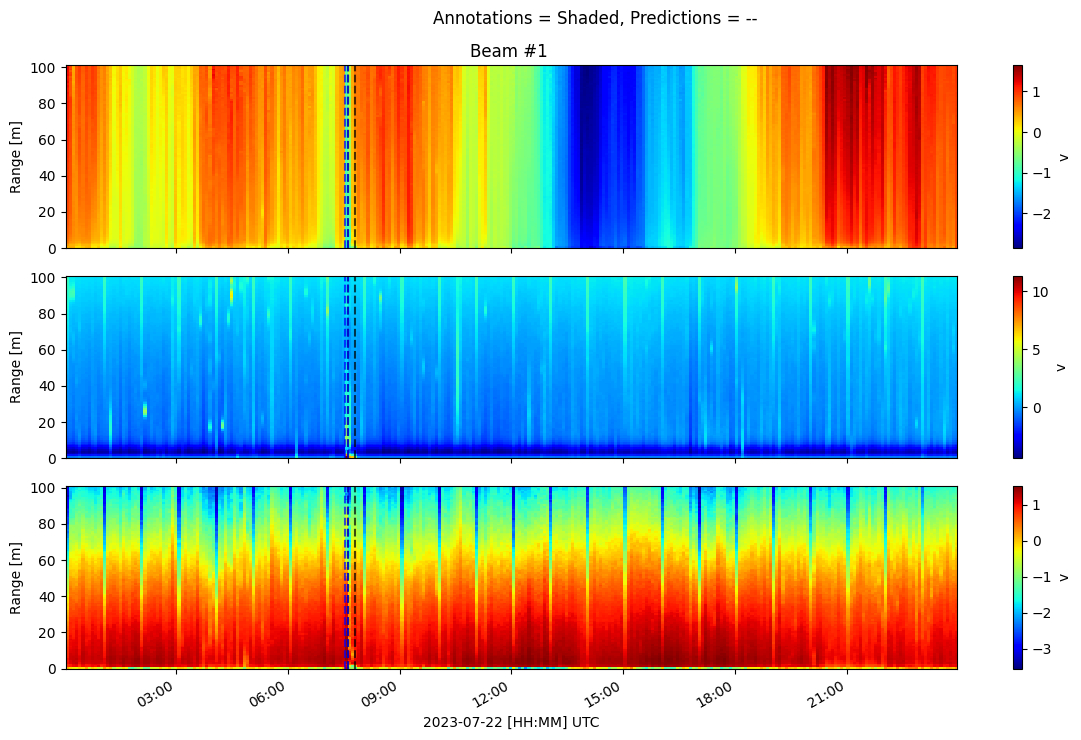

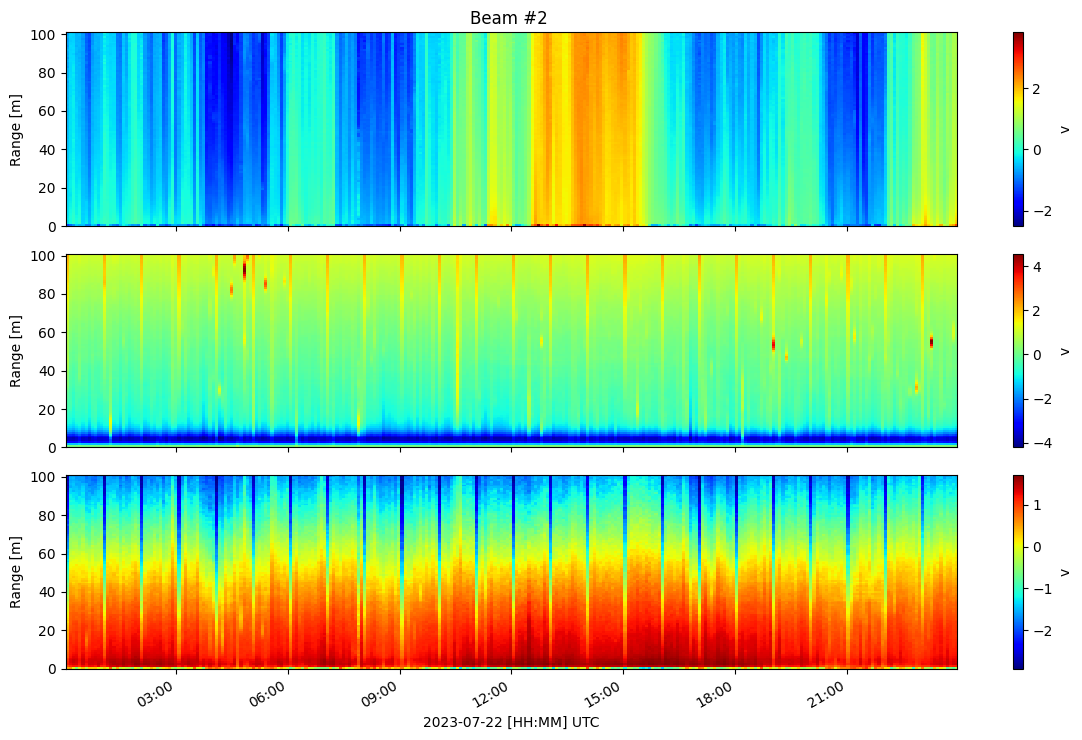

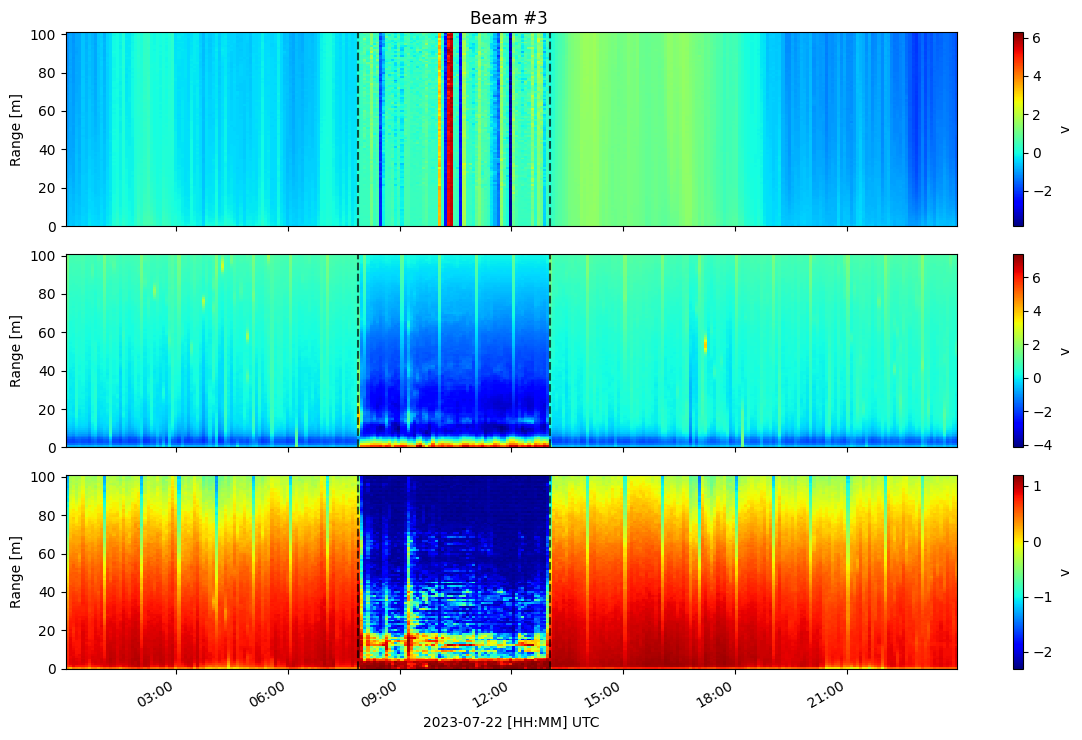

Drop-outs found in Beam [2]! In F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\20230722T000000_20230722T235959.h5


In [ ]:


#THIS IS DEVELOPMENT CODE THAT WAS USED TO UPDATE "detect_nortek_dropouts" 

#Classify multiple hourly h5 files at once (after all the monthly mats have been converted to 24hr h5 files):

import os
import sys
import importlib
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import datetime 

# Ensure repo root is available when running this cell independently
repo_root = Path().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

#from dev import detect_nortek_dropouts
from src import detect_nortek_dropouts
#import detect_nortek_dropouts

# For debugging hot-reload during notebook iteration
importlib.reload(detect_nortek_dropouts)

# Monthly Mat data to convert (directory path, it will find the mat files)
data_parent = r'F:\Documents\Projects\ADCP\scan_for_data\BACUS\ADCP2MHZ\\'

# For one specific folder:
#folder_list = ['20240801']

# folder_list = ['20131101', '20141201', '20161101', '20170501',
#                 '20220101', '20220201', '20220601', '20220801',
#                 '20221001', '20230201', '20230701', '20240201',
#                 '20240801', '20250201']

#folder_list = ['20250701']
#folder_list = ['20251201']
folder_list = ['20230701']




# Inputs:
variant = 'resnet50'
#variant = 'TemporalCNN'

if variant == 'TemporalCNN':
    model_path = r"F:\Documents\GitHub\ml_development\ADCP_ML\src\\models\\" + "best_model_20250508.pt"
else:
    model_path = r"F:\Documents\GitHub\ml_development\ADCP_ML\src\\models\\" + f"best_model_{variant}.pt"

h5_monthly_folder = r'F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_files\\'  # Monthly h5 output
h5_24hr_folder = r'F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\'   # 24hr h5 output


#Batch size: Specify number of 24-hr files to push through the model at once.
#Too few, and it takes a long time to classify all the files. Too many, and it runs out of memory.
num_beams = 3 # DO NOT CHANGE THIS
num_days = 7 # Number of 24hr files to classify at once (adjust based on memory constraints)
batch_size = num_beams*num_days

#Set this to 1 to delete the 24 hr h5 files that are created from each monthly file (recomended) 
do_delete = 0

#Set to make plots. Caution: Can consume a lot of memory if classifying many files at once, since it needs to store the input data for plotting.
create_plots = 1


# Create a text file for keeping track of detections
log_path = os.path.join(h5_24hr_folder, f"dropout_detections_{variant}_{datetime.datetime.now().strftime('%Y%m%dT%H%M')}.txt")
with open(log_path, "w") as f:
    f.write("start_time, end_time, class, beam, duration_minutes\n")

# Build full list of .mat files
mat_paths = []
for folder in folder_list:
    file_list = os.listdir(data_parent + folder)
    mat_files = {k for k in file_list if os.path.splitext(k)[1] == ".mat"}
    print(mat_files)
    for filename in mat_files:
        mat_paths.append(data_parent + folder + '\\' + filename)

def prepare_24hr_from_mat(mat_path):
    """Convert monthly mat -> monthly h5 -> split into 24hr h5 files."""
    detect_nortek_dropouts.convert_monthly_mat_to_h5.extract_mat_to_h5(mat_path, h5_monthly_folder)
    filename_h5 = os.path.splitext(os.path.basename(mat_path))[0] + '.h5'
    input_file = h5_monthly_folder + filename_h5
    #detect_nortek_dropouts.split_h5_to_24hr_files.split_h5_to_24hr_files_with_ann(
    detect_nortek_dropouts.split_h5_to_24hr_files_noEmbed.split_h5_to_24hr_files(
        input_file,
        h5_24hr_folder,
    )
    return mat_path

# Parallel prep step (I/O-heavy); classify once afterward
max_workers = min(4, max(1, len(mat_paths)))
if mat_paths:
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(prepare_24hr_from_mat, mat_path) for mat_path in mat_paths]
        for future in as_completed(futures):
            try:
                done_path = future.result()
                print(f"Prepared 24hr files from: {os.path.basename(done_path)}")
            except Exception as e:
                print(f"Failed to prepare one mat file: {e}")

# Classify all generated 24hr files once
model = detect_nortek_dropouts.init_model(model_path)
file_list = os.listdir(h5_24hr_folder)
h5_files = sorted(k for k in file_list if os.path.splitext(k)[1] == ".h5")
detect_nortek_dropouts.classify_and_plot(model, h5_files, h5_24hr_folder, log_path, create_plots=create_plots, batch_size=batch_size)

# Optional cleanup once complete
if do_delete:
    for h5_folder in {h5_monthly_folder, h5_24hr_folder}:
        file_list = os.listdir(h5_folder)
        h5_files = sorted(k for k in file_list if k.endswith(".h5"))
        for h5_file in h5_files:
            full_path = os.path.join(h5_folder, h5_file)
            try:
                os.remove(full_path)
                print(f"Deleted {h5_file}")
            except Exception as e:
                print(f"Failed to delete {h5_file}: {e}")

In [16]:
#DEBUG

#from dev import detect_nortek_dropouts
from src import detect_nortek_dropouts
# For debugging hot-reload during notebook iteration
importlib.reload(detect_nortek_dropouts)

#Use a smaller subset of data
h5_files = ['20251223T000000_20251223T235959.h5',
 '20251224T000000_20251224T235959.h5',
 '20251225T000000_20251225T235959.h5',
 '20251226T000000_20251226T235959.h5',
 '20251227T000000_20251227T235959.h5',
 '20251228T000000_20251228T235959.h5',
 '20251229T000000_20251229T235959.h5']


#Batch size: Specify number of 24-hr files to push through the model at once.

#Too few, and it takes a long time to classify all the files. Too many, and it runs out of memory.
num_beams = 3 # DO NOT CHANGE THIS
num_days = 2 # Number of 24hr files to classify at once (adjust based on memory constraints)
batch_size = num_beams*num_days



# Classify all generated 24hr files once
model = detect_nortek_dropouts.init_model(model_path)
#file_list = os.listdir(h5_24hr_folder)
#h5_files = sorted(k for k in file_list if os.path.splitext(k)[1] == ".h5")


detect_nortek_dropouts.classify_and_plot(model, h5_files, h5_24hr_folder, log_path, create_plots=1, batch_size=batch_size)

'''
#Combine paths into a list
h5_24hr_files = []
for h5_file in h5_files:
    h5_24hr_files.append(h5_24hr_folder + h5_file) 
    #print(h5_24hr_folder)
    #print(h5_file)
        
#Run the classification
print(f'Running drop-out detection on all 24 hr files')
#If not creating plots, don't store the input data (x), since it can take a lot of memory, and is only really needed for plotting
x, y, preds, meta = detect_nortek_dropouts.classify_test_data(model, h5_24hr_files, batch_size=batch_size)
'''

📌 Initializing ResNet model (resnet50)


c:\Users\slonimer\AppData\Local\miniconda3\envs\adcp_anomaly_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\slonimer\AppData\Local\miniconda3\envs\adcp_anomaly_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Loaded pretrained weights with 2 missing and 0 unexpected keys

=== Starting Evaluation on Test Set ===
Running drop-out detection on all 24 hr files
Loading: ['F:\\Documents\\Projects\\ML\\ADCP_ML\\BACUS\\h5_24h_files\\\\20251223T000000_20251223T235959.h5', 'F:\\Documents\\Projects\\ML\\ADCP_ML\\BACUS\\h5_24h_files\\\\20251224T000000_20251224T235959.h5', 'F:\\Documents\\Projects\\ML\\ADCP_ML\\BACUS\\h5_24h_files\\\\20251225T000000_20251225T235959.h5', 'F:\\Documents\\Projects\\ML\\ADCP_ML\\BACUS\\h5_24h_files\\\\20251226T000000_20251226T235959.h5', 'F:\\Documents\\Projects\\ML\\ADCP_ML\\BACUS\\h5_24h_files\\\\20251227T000000_20251227T235959.h5', 'F:\\Documents\\Projects\\ML\\ADCP_ML\\BACUS\\h5_24h_files\\\\20251228T000000_20251228T235959.h5', 'F:\\Documents\\Projects\\ML\\ADCP_ML\\BACUS\\h5_24h_files\\\\20251229T000000_20251229T235959.h5']
Processed batch 1 with shape torch.Size([6, 3, 288, 102]), predictions shape torch.Size([1728]), labels shape torch.Size([1728])
Processed batch 

"\n#Combine paths into a list\nh5_24hr_files = []\nfor h5_file in h5_files:\n    h5_24hr_files.append(h5_24hr_folder + h5_file) \n    #print(h5_24hr_folder)\n    #print(h5_file)\n        \n#Run the classification\nprint(f'Running drop-out detection on all 24 hr files')\n#If not creating plots, don't store the input data (x), since it can take a lot of memory, and is only really needed for plotting\nx, y, preds, meta = detect_nortek_dropouts.classify_test_data(model, h5_24hr_files, batch_size=batch_size)\n"

In [3]:
#DEBUG

#from dev import detect_nortek_dropouts
from src import detect_nortek_dropouts
#import detect_nortek_dropouts

# For debugging hot-reload during notebook iteration
importlib.reload(detect_nortek_dropouts)

if variant == 'TemporalCNN':
    model_path = r"F:\Documents\GitHub\ml_development\ADCP_ML\\src\\models\\" + "best_model_20250508.pt"
else:
    model_path = r"F:\Documents\GitHub\ml_development\ADCP_ML\\src\\models\\" + f"best_model_{variant}.pt"


# Classify all generated 24hr files once
model = detect_nortek_dropouts.init_model(model_path)
file_list = os.listdir(h5_24hr_folder)
h5_files = sorted(k for k in file_list if os.path.splitext(k)[1] == ".h5")
detect_nortek_dropouts.classify_and_plot(model, h5_files, h5_24hr_folder, log_path, create_plots=0)

# Optional cleanup once complete
if do_delete:
    for h5_folder in {h5_monthly_folder, h5_24hr_folder}:
        file_list = os.listdir(h5_folder)
        h5_files = sorted(k for k in file_list if k.endswith(".h5"))
        for h5_file in h5_files:
            full_path = os.path.join(h5_folder, h5_file)
            try:
                os.remove(full_path)
                print(f"Deleted {h5_file}")
            except Exception as e:
                print(f"Failed to delete {h5_file}: {e}")

📌 Initializing ResNet model (resnet50)
✅ Loaded pretrained weights with 267 missing and 320 unexpected keys

=== Starting Evaluation on Test Set ===
F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\
20131101T000230_20131102T000229.h5
F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\
20131102T000000_20131102T235959.h5
F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\
20131103T000000_20131103T235959.h5
F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\
20131104T000000_20131104T235959.h5
F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\
20131105T000000_20131105T235959.h5
F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\
20131106T000000_20131106T235959.h5
F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\
20131107T000000_20131107T235959.h5
F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\
20131108T000000_20131108T235959.h5
F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_files\\
20131109T000000_20131109T235959.h5
F:\Documents\Projects\ML\ADCP_ML\BACUS\h5_24h_file

OSError: Unable to synchronously open file (file signature not found)